# Proyecto Final — Data Science II

# BTC / DXY / Oro / VIX

## Notebook 03 — Adquisición Oro mediante rangos temporales fijos

Curso: Data Science II — Machine Learning para Ciencia de Datos  
Coderhouse | 2025–2026

---

Este notebook corresponde a la etapa de adquisición definitiva de datos del Oro para el proyecto BTC/DXY/Oro/VIX.

El Oro será utilizado como activo macro-financiero de comparación frente al comportamiento de Bitcoin, debido a su rol histórico como reserva de valor y activo refugio.

La finalidad de este bloque es construir un dataset reproducible, validado y exportable, manteniendo la misma lógica modular aplicada previamente en los notebooks de BTC y DXY.

El dataset obtenido en este notebook formará parte de la Fase 1 del pipeline maestro del proyecto y será utilizado posteriormente en la integración multi-activo.

# Contexto metodológico

En los notebooks anteriores se consolidó la estructura base del pipeline modular:

- adquisición mediante rango temporal fijo,
- limpieza estructural del DataFrame,
- validación estructural y temporal,
- construcción de variables iniciales,
- validación de valores faltantes,
- EDA de validación,
- logging básico,
- y export del dataset procesado.

En este notebook se reutiliza esa arquitectura para adquirir y validar datos históricos del Oro.

La decisión metodológica principal es mantener consistencia entre activos, utilizando:

- el mismo rango temporal oficial,
- la misma frecuencia diaria,
- una estructura de validación comparable,
- y un output procesado reutilizable para etapas posteriores.

# Rango temporal y fuente de datos

El rango temporal oficial del proyecto será:

| Inicio | Fin |
|---|---|
| 2023-05-06 | 2026-05-06 |

Frecuencia:
- diaria

Fuente:
- Yahoo Finance mediante `yfinance`

Ticker utilizado:
- `GC=F`

---

El ticker `GC=F` corresponde a futuros de Oro en Yahoo Finance. Se utiliza como proxy del comportamiento histórico del precio del Oro dentro del rango temporal definido.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Adquisición de datos desde Yahoo Finance

Se realizará la descarga histórica del Oro mediante Yahoo Finance utilizando el ticker `GC=F`.

La adquisición se realiza con:

- rango temporal fijo,
- frecuencia diaria,
- y datos OHLCV completos.

Esto permite mantener reproducibilidad y consistencia metodológica respecto a los activos adquiridos previamente.

In [2]:
gold_df = yf.download(
    "GC=F",
    start="2023-05-06",
    end="2026-05-07",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [3]:
gold_df.head()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2023-05-08,2026.300049,2026.300049,2022.500000,2022.500000,3
2023-05-09,2036.199951,2037.300049,2025.900024,2026.599976,241
2023-05-10,2030.500000,2044.300049,2029.500000,2032.300049,248
2023-05-11,2014.699951,2038.300049,2014.000000,2034.099976,90
2023-05-12,2014.500000,2014.500000,2014.500000,2014.500000,115


# 2. Exploración inicial y simplificación de la estructura MultiIndex

In [4]:
gold_df.columns = gold_df.columns.droplevel(1)

In [6]:
gold_df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-08,2026.300049,2026.300049,2022.500000,2022.500000,3
2023-05-09,2036.199951,2037.300049,2025.900024,2026.599976,241
2023-05-10,2030.500000,2044.300049,2029.500000,2032.300049,248
2023-05-11,2014.699951,2038.300049,2014.000000,2034.099976,90
2023-05-12,2014.500000,2014.500000,2014.500000,2014.500000,115


In [7]:
gold_df.columns.name = None

In [8]:
gold_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

# 3. Validación estructural y temporal del dataset Oro

Antes de continuar con la construcción de features y análisis exploratorio, se realizan validaciones básicas de integridad estructural sobre el dataset adquirido.

Las siguientes verificaciones buscan confirmar:

- consistencia temporal,
- ausencia de duplicados,
- continuidad del rango temporal,
- y coherencia general de la estructura del dataset.

In [9]:
print("=== VALIDACIÓN ESTRUCTURAL ORO ===")

print(f"Shape del dataset: {gold_df.shape}")

print(
    f"Rango temporal: "
    f"{gold_df.index.min().date()} "
    f"→ "
    f"{gold_df.index.max().date()}"
)

print(
    f"Orden cronológico correcto: "
    f"{gold_df.index.is_monotonic_increasing}"
)

print(
    f"Duplicados temporales: "
    f"{gold_df.index.duplicated().sum()}"
)

print(
    f"Gaps temporales detectados: "
    f"{(gold_df.index.to_series().diff().dropna() != pd.Timedelta(days=1)).sum()}"
)

print(
    "Nota: en Oro los gaps temporales son esperados "
    "por calendario financiero (fines de semana y feriados)."
)

=== VALIDACIÓN ESTRUCTURAL ORO ===
Shape del dataset: (754, 5)
Rango temporal: 2023-05-08 → 2026-05-06
Orden cronológico correcto: True
Duplicados temporales: 0
Gaps temporales detectados: 167
Nota: en Oro los gaps temporales son esperados por calendario financiero (fines de semana y feriados).


# 4. Construcción de features iniciales

Se construirán variables financieras básicas sobre el precio del Oro con el objetivo de generar señales iniciales para análisis posteriores.

Las features construidas serán:

- retorno porcentual diario (`return`),
- volatilidad móvil de 7 días (`volatility_7d`),
- y media móvil de 7 días (`ma_7d`).

Estas variables permiten describir comportamiento, dispersión y tendencia del activo dentro del rango temporal analizado.

### 4.1. Retorno porcentual diario

In [10]:
gold_df["return"] = gold_df["Close"].pct_change()

### 4.2. Volatilidad rolling de 7 días

In [11]:
gold_df["volatility_7d"] = (
    gold_df["return"]
    .rolling(7)
    .std()
)

### 4.3. Media Movil de 7 días

In [12]:
gold_df["ma_7d"] = (
    gold_df["Close"]
    .rolling(7)
    .mean()
)

# 5. Validación de features y valores faltantes

Las features rolling y los retornos porcentuales generan valores faltantes al inicio de la serie debido a la imposibilidad matemática de calcular ventanas previas inexistentes.

Esta validación permite confirmar que:

- los NaN observados son esperados,
- las columnas fueron construidas correctamente,
- y no existen pérdidas anómalas de información.

In [13]:
print("=== VALIDACIÓN DE NaN ===")

print(
    f"NaN en return: "
    f"{gold_df['return'].isna().sum()}"
)

print(
    f"NaN en volatility_7d: "
    f"{gold_df['volatility_7d'].isna().sum()}"
)

print(
    f"NaN en ma_7d: "
    f"{gold_df['ma_7d'].isna().sum()}"
)

=== VALIDACIÓN DE NaN ===
NaN en return: 1
NaN en volatility_7d: 7
NaN en ma_7d: 6


# 6. Visualización inicial del Oro

Se visualiza la evolución temporal del precio del Oro dentro del rango oficial del proyecto.

El objetivo de esta visualización es:

- observar comportamiento general del activo,
- identificar tendencias relevantes,
- detectar posibles períodos de estabilidad o tensión,
- y validar coherencia visual de la serie temporal adquirida.

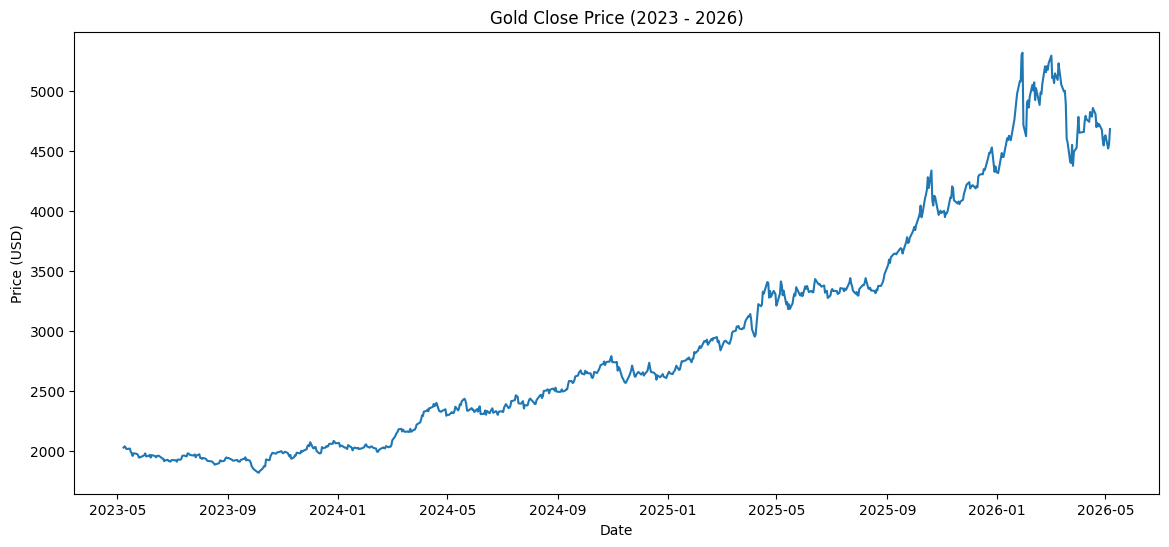

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    gold_df.index,
    gold_df["Close"]
)

plt.title("Gold Close Price (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.show()

## Lectura inicial del comportamiento del Oro
El Oro presenta un comportamiento claramente distinto respecto a los activos analizados previamente.

A diferencia del DXY, cuyo comportamiento general fue relativamente lateral, el Oro muestra una tendencia alcista sostenida durante gran parte del período analizado, con una aceleración especialmente marcada hacia finales de 2025 e inicios de 2026.

Aunque el Oro mantiene una volatilidad considerablemente menor que Bitcoin, ambos activos parecen compartir ciertos comportamientos direccionales en algunos períodos del rango temporal observado, especialmente durante fases de debilitamiento del dólar.

Esto sugiere que tanto BTC como Oro podrían reaccionar parcialmente ante contextos macro-financieros similares, aunque con intensidades y velocidades distintas.

También puede observarse que el Oro desarrolla tendencias más prolongadas y estructuralmente más limpias que Bitcoin, reflejando su naturaleza histórica como activo defensivo y reserva de valor dentro del sistema financiero global.

La aceleración observada durante 2025–2026 será relevante en futuras etapas del análisis multi-activo, especialmente al comparar la relación entre Oro, BTC y DXY.

# 7. Visualización de retornos diarios del Oro

Se visualiza la variación porcentual diaria del Oro con el objetivo de observar:

- intensidad de movimientos diarios,
- estabilidad relativa del activo,
- y comportamiento temporal de los retornos.

Esto permite contextualizar la volatilidad del Oro respecto a otros activos analizados previamente dentro del proyecto.

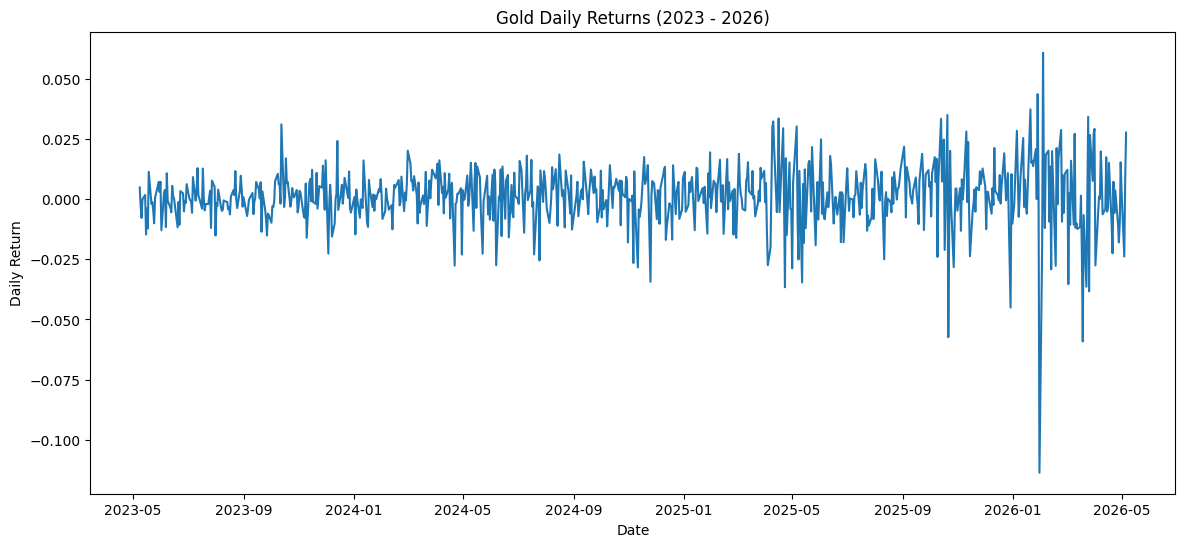

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    gold_df.index,
    gold_df["return"]
)

plt.title("Gold Daily Returns (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

## Lectura inicial de retornos diarios del Oro
La visualización de retornos diarios permite observar que el Oro posee una volatilidad considerablemente menor que Bitcoin en condiciones normales, aunque presenta episodios de tensión relevantes en determinados períodos del rango analizado.

La mayoría de los movimientos diarios del activo se mantienen dentro de rangos relativamente moderados, generalmente cercanos al ±1% o ±2%.

Sin embargo, también pueden observarse spikes de volatilidad considerablemente más agresivos durante ciertos momentos específicos, especialmente hacia finales de 2025 e inicios de 2026.

Estos movimientos reflejan la sensibilidad del Oro frente a eventos macro-financieros, contextos de incertidumbre, cambios en expectativas económicas y movimientos relevantes del dólar estadounidense.

En comparación con el DXY, el Oro muestra retornos diarios más amplios y dinámicos. Y aunque continúa siendo estructuralmente menos violento que Bitcoin, presenta una capacidad de reacción considerablemente mayor que los índices macro tradicionales.

Esto refuerza el rol del Oro como activo defensivo sensible a tensiones financieras globales, aspecto que será relevante en etapas posteriores del análisis multi-activo.

# 8. Volatilidad móvil de 7 días

Se visualiza la volatilidad móvil de 7 días del Oro con el objetivo de identificar:

- períodos de mayor tensión financiera,
- cambios en intensidad de movimiento,
- y fases de estabilidad relativa del activo.

La volatilidad rolling permite suavizar el ruido diario y observar cómo evoluciona la dispersión de los retornos a lo largo del tiempo.

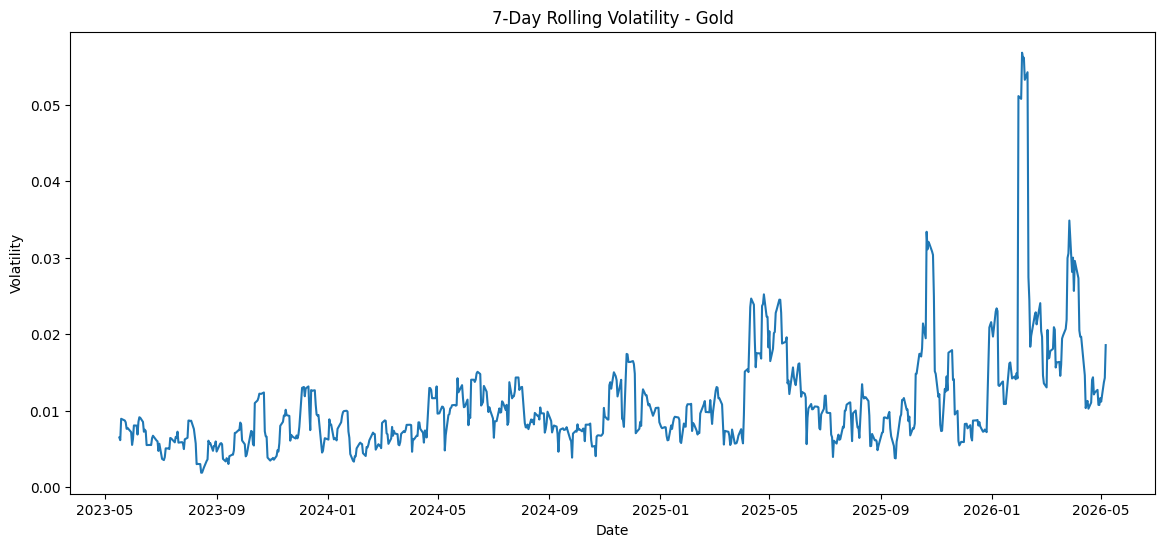

In [19]:
plt.figure(figsize=(14,6))

plt.plot(
    gold_df.index,
    gold_df["volatility_7d"]
)

plt.title("7-Day Rolling Volatility - Gold")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Lectura inicial de volatilidad móvil del Oro
La volatilidad móvil de 7 días muestra que el Oro presenta períodos de tensión relativamente sostenidos, especialmente hacia finales de 2025 e inicios de 2026.

A diferencia de movimientos aislados extremadamente abruptos, el activo parece desarrollar pequeños regímenes temporales de volatilidad elevada, donde la dispersión de los retornos permanece alta durante varios días consecutivos antes de normalizarse nuevamente.

Este comportamiento resulta coherente con la naturaleza macro-financiera del Oro, ya que suele reaccionar ante contextos de incertidumbre económica, tensiones geopolíticas, expectativas de tasas de interés y movimientos relevantes del dólar estadounidense.

También puede observarse que la volatilidad del activo aumenta progresivamente hacia el tramo final del período analizado, acompañando la aceleración alcista observada previamente en el precio del Oro.

En comparación con los otros activos analizados:

- Bitcoin presenta volatilidad estructuralmente más extrema y explosiva,
- el DXY mantiene movimientos considerablemente más contenidos,
- mientras que el Oro parece ubicarse en una posición intermedia, combinando estabilidad relativa con episodios de tensión sostenida.

Estas diferencias de régimen entre activos serán relevantes en futuras etapas de integración y análisis multi-activo.

# 9. Media móvil de 7 días

Se visualiza la media móvil de 7 días del Oro con el objetivo de suavizar fluctuaciones diarias y observar con mayor claridad el comportamiento tendencial del activo.

La media móvil permite reducir parte del ruido presente en los retornos diarios y facilita la identificación de:

- tendencias generales,
- cambios progresivos de dirección,
- y fases de aceleración o desaceleración del precio.

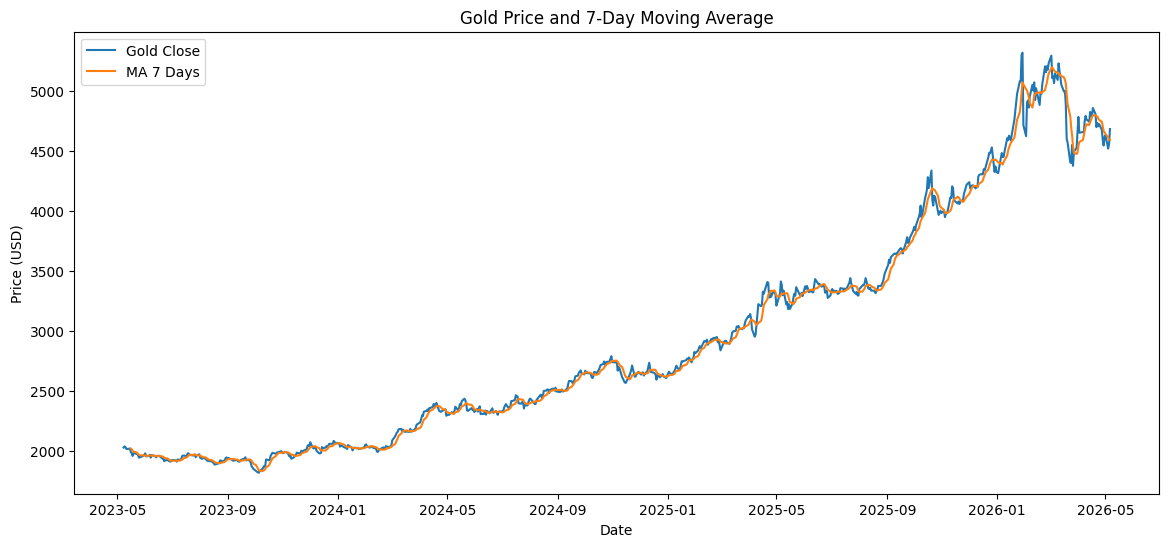

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    gold_df.index,
    gold_df["Close"],
    label="Gold Close"
)

plt.plot(
    gold_df.index,
    gold_df["ma_7d"],
    label="MA 7 Days"
)

plt.title("Gold Price and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()

plt.show()

## Lectura inicial de la media móvil del Oro
La media móvil de 7 días muestra un comportamiento relativamente estable y cercano al precio del Oro durante gran parte del período analizado.

Esto refleja que el activo mantuvo una dinámica tendencial relativamente ordenada, con movimientos progresivos y volatilidad moderada en comparación con Bitcoin.

Sin embargo, hacia finales de 2025 e inicios de 2026 puede observarse una aceleración considerable del precio, generando un desacople más visible entre el valor real del activo y su media móvil.

Este comportamiento sugiere un incremento repentino en intensidad de movimiento y momentum del mercado, acompañado por mayores niveles de volatilidad observados previamente en los retornos diarios y en la volatilidad rolling.

A diferencia de Bitcoin — donde los desacoples respecto a la media móvil pueden ser frecuentes y extremadamente agresivos — el Oro parece mantener una relación más estable con su tendencia suavizada, separándose de forma significativa únicamente durante períodos de tensión o aceleración excepcionales.

En comparación con los otros activos analizados:

- el DXY permanece muy cercano a su media móvil durante casi todo el período,
- Bitcoin presenta desacoples frecuentes y violentos,
- mientras que el Oro combina estabilidad tendencial con episodios puntuales de aceleración relevante.

Estas diferencias estructurales entre activos serán importantes en las etapas posteriores de integración y análisis financiero multi-activo.

# 10. Export del dataset procesado

Luego de finalizar la adquisición, validación y construcción inicial de features, el dataset procesado del Oro será exportado hacia la carpeta `data/processed/`.

Este archivo funcionará como input reutilizable para las siguientes etapas del pipeline multi-activo del proyecto.

In [21]:
import os

PROJECT_PATH = r"C:\DS2_BTC_DXY_ORO_VIX"

processed_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

os.makedirs(processed_path, exist_ok=True)

gold_df.to_csv(
    os.path.join(
        processed_path,
        "gold_processed.csv"
    ),
    encoding="utf-8-sig"
)

print("=== EXPORT FINALIZADO ===")

print("Archivo exportado correctamente hacia:")

print(
    os.path.join(
        processed_path,
        "gold_processed.csv"
    )
)

=== EXPORT FINALIZADO ===
Archivo exportado correctamente hacia:
C:\DS2_BTC_DXY_ORO_VIX\data\processed\gold_processed.csv
